# Effective current fields for the Kiel Bight

Building velocity fields that combine Eulerian currents with wave-driven
Stokes drift at each depth level. The CMEMS Baltic wave model provides
partitioned wave parameters (wind waves, primary and secondary swell),
from which we construct a Stokes drift profile using the deep-water
monochromatic approximation per partition. Adding this to the Eulerian
currents gives the effective current that a Lagrangian particle experiences.

This notebook produces the input fields for Parcels runs but does not
use Parcels itself.

## Imports

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

## Parameters

In [ ]:
LON_BDS = [9.5, 11.5]
LAT_BDS = [54.0, 55.5]
TIME_START = "2023-04-24"
TIME_END = "2023-04-27"
CMEMS_DIR = "data/cmems"

## Load Eulerian currents

CMEMS Baltic physics analysis (hourly, native grid). We load the full
depth range from 0 to 5 m, which gives us several near-surface levels
where the Stokes drift contribution matters most.

In [ ]:
LON = slice(*LON_BDS)
LAT = slice(*LAT_BDS)
TIME = slice(TIME_START, TIME_END)

ds_phy = xr.open_dataset(CMEMS_DIR + "/cmems_mod_bal_phy_anfc_PT1H-i.nc").sel(
    longitude=LON, latitude=LAT, time=TIME,
).load()

ds_phy

## Load wave partition data

CMEMS Baltic wave analysis (hourly). We load the partitioned wave
parameters: significant wave height, mean period, and mean direction
for wind waves (WW), primary swell (SW1), and secondary swell (SW2).

In [ ]:
WAVE_VARS = [
    "VHM0_WW", "VTM01_WW", "VMDR_WW",
    "VHM0_SW1", "VTM01_SW1", "VMDR_SW1",
    "VHM0_SW2", "VTM01_SW2", "VMDR_SW2",
]

ds_wav = xr.open_dataset(CMEMS_DIR + "/cmems_mod_bal_wav_anfc_PT1H-i.nc").sel(
    longitude=LON, latitude=LAT, time=TIME,
)[WAVE_VARS].load()

ds_wav

## Build Stokes drift profiles

For each wave partition (wind waves, primary swell, secondary swell), the
Stokes drift profile under the deep-water monochromatic approximation is:

$$u_{\mathrm{St},i}(z) = A_i^2 \, \sigma_i \, k_i \, e^{2 k_i z} \, \hat{d}_i$$

where $A_i = H_{s,i}/2$ is the amplitude, $\sigma_i = 2\pi / T_i$ the
angular frequency, $k_i = \sigma_i^2 / g$ the deep-water wavenumber, and
$\hat{d}_i$ is the unit direction vector. The CMEMS direction convention is
meteorological ("coming from"), so we convert:
$\theta = (270° - \mathrm{dir_{from}})$ in radians.

We evaluate this at each depth level of the Eulerian grid, sum over all
wave components, and interpolate onto the physics grid.

In [5]:
g = 9.81
depth_levels = ds_phy.depth.values  # positive-down depth coordinate

# Partitions: (Hs variable, period variable, direction variable)
PARTITIONS = [
    ("VHM0_WW", "VTM01_WW", "VMDR_WW"),
    ("VHM0_SW1", "VTM01_SW1", "VMDR_SW1"),
    ("VHM0_SW2", "VTM01_SW2", "VMDR_SW2"),
]

# Accumulate Stokes drift on the wave grid, with a depth dimension
u_stokes = xr.DataArray(
    np.zeros((len(ds_wav.time), len(depth_levels), len(ds_wav.latitude), len(ds_wav.longitude))),
    dims=["time", "depth", "latitude", "longitude"],
    coords={"time": ds_wav.time, "depth": depth_levels,
            "latitude": ds_wav.latitude, "longitude": ds_wav.longitude},
)
v_stokes = u_stokes.copy()

for hs_var, t_var, dir_var in PARTITIONS:
    hs = ds_wav[hs_var]
    T = ds_wav[t_var]
    dir_from = ds_wav[dir_var]

    # Filter negligible wave components
    valid = hs > 0.01

    A = hs / 2
    sigma = 2 * np.pi / T
    k = sigma**2 / g
    theta = np.deg2rad(270.0 - dir_from)

    # Stokes magnitude at surface: A^2 * sigma * k
    stokes_surf = A**2 * sigma * k

    for i, z in enumerate(depth_levels):
        # z is positive-down depth, Stokes formula uses negative z (below surface)
        decay = np.exp(-2 * k * float(z))
        u_component = (stokes_surf * decay * np.cos(theta)).where(valid, 0.0)
        v_component = (stokes_surf * decay * np.sin(theta)).where(valid, 0.0)
        u_stokes[dict(depth=i)] += u_component.fillna(0.0)
        v_stokes[dict(depth=i)] += v_component.fillna(0.0)

print(f"Stokes drift computed at {len(depth_levels)} depth levels: {depth_levels}")

Stokes drift computed at 5 depth levels: [0.5016462 1.5159924 2.548084  3.6022985 4.684081 ]


## Interpolate Stokes onto the physics grid

The wave and physics grids differ slightly. We interpolate the Stokes
drift fields onto the physics grid coordinates so they can be added
directly to the Eulerian currents.

In [6]:
ds_stokes = xr.Dataset({"u_stokes": u_stokes, "v_stokes": v_stokes})

# Interpolate onto physics grid
ds_stokes_phys = ds_stokes.interp(
    longitude=ds_phy.longitude,
    latitude=ds_phy.latitude,
    method="linear",
).fillna(0.0)

# Apply land mask from Eulerian data (where uo is NaN, set Stokes to NaN too)
land_mask = ds_phy["uo"].isnull()
ds_stokes_phys["u_stokes"] = ds_stokes_phys["u_stokes"].where(~land_mask)
ds_stokes_phys["v_stokes"] = ds_stokes_phys["v_stokes"].where(~land_mask)

ds_stokes_phys

<xarray.Dataset> Size: 50MB
Dimensions:    (time: 96, depth: 5, latitude: 90, longitude: 72)
Coordinates:
  * time       (time) datetime64[ns] 768B 2023-04-24 ... 2023-04-27T23:00:00
  * depth      (depth) float32 20B 0.5016 1.516 2.548 3.602 4.684
  * latitude   (latitude) float32 360B 54.01 54.02 54.04 ... 55.46 55.47 55.49
  * longitude  (longitude) float32 288B 9.514 9.542 9.569 ... 11.43 11.46 11.49
Data variables:
    u_stokes   (time, depth, latitude, longitude) float64 25MB nan nan ... nan
    v_stokes   (time, depth, latitude, longitude) float64 25MB nan nan ... nan

## Build effective current

The effective current at each depth is the sum of the Eulerian current
and the Stokes drift. We store the result as a new Dataset with the
same structure as the physics data, so it can be loaded directly into
a Parcels FieldSet.

In [7]:
ds_eff = xr.Dataset(
    {
        "U_eff": ds_phy["uo"] + ds_stokes_phys["u_stokes"],
        "V_eff": ds_phy["vo"] + ds_stokes_phys["v_stokes"],
    },
    attrs={"description": "Effective current: Eulerian + Stokes drift profile"},
)

# Preserve the Eulerian and Stokes components for inspection
ds_eff["uo"] = ds_phy["uo"]
ds_eff["vo"] = ds_phy["vo"]
ds_eff["u_stokes"] = ds_stokes_phys["u_stokes"]
ds_eff["v_stokes"] = ds_stokes_phys["v_stokes"]

ds_eff

<xarray.Dataset> Size: 124MB
Dimensions:    (depth: 5, latitude: 90, longitude: 72, time: 96)
Coordinates:
  * depth      (depth) float32 20B 0.5016 1.516 2.548 3.602 4.684
  * latitude   (latitude) float32 360B 54.01 54.02 54.04 ... 55.46 55.47 55.49
  * longitude  (longitude) float32 288B 9.514 9.542 9.569 ... 11.43 11.46 11.49
  * time       (time) datetime64[ns] 768B 2023-04-24 ... 2023-04-27T23:00:00
Data variables:
    U_eff      (time, depth, latitude, longitude) float64 25MB nan nan ... nan
    V_eff      (time, depth, latitude, longitude) float64 25MB nan nan ... nan
    uo         (time, depth, latitude, longitude) float32 12MB nan nan ... nan
    vo         (time, depth, latitude, longitude) float32 12MB nan nan ... nan
    u_stokes   (time, depth, latitude, longitude) float64 25MB nan nan ... nan
    v_stokes   (time, depth, latitude, longitude) float64 25MB nan nan ... nan
Attributes:
    description:  Effective current: Eulerian + Stokes drift profile

## Visualize

Comparing Eulerian, Stokes, and effective current speeds at the
shallowest depth level (near-surface) and at the deepest available
level (~4.7 m). Each row shows a time-mean map of the speed field.
Coordinates are regularized with linspace so that pcolormesh works
on the slightly irregular CMEMS grid.

In [ ]:
# Regularize coordinates for plotting
ds_plot = ds_eff.assign_coords(
    longitude=np.linspace(
        float(ds_eff.longitude[0]), float(ds_eff.longitude[-1]), len(ds_eff.longitude)
    ),
    latitude=np.linspace(
        float(ds_eff.latitude[0]), float(ds_eff.latitude[-1]), len(ds_eff.latitude)
    ),
)

# Compute time-mean speeds
euler_speed = np.sqrt(ds_plot["uo"]**2 + ds_plot["vo"]**2).mean("time")
stokes_speed = np.sqrt(ds_plot["u_stokes"]**2 + ds_plot["v_stokes"]**2).mean("time")
eff_speed = np.sqrt(ds_plot["U_eff"]**2 + ds_plot["V_eff"]**2).mean("time")

# Two depth levels: shallowest and deepest
z_shallow = ds_eff.depth.values[0]
z_deep = ds_eff.depth.values[-1]

# Global color scale: P95 across all panels and both depths
all_speeds = np.concatenate([
    euler_speed.values.ravel(),
    stokes_speed.values.ravel(),
    eff_speed.values.ravel(),
])
vmax = float(np.nanpercentile(all_speeds, 95))

fig, axes = plt.subplots(2, 3)

for row, z in enumerate([z_shallow, z_deep]):
    kw = dict(vmin=0, vmax=vmax, extend="max")

    euler_speed.sel(depth=z).plot(ax=axes[row, 0], **kw)
    axes[row, 0].set_title(f"Eulerian (z={z:.1f} m)")

    stokes_speed.sel(depth=z).plot(ax=axes[row, 1], **kw)
    axes[row, 1].set_title(f"Stokes (z={z:.1f} m)")

    eff_speed.sel(depth=z).plot(ax=axes[row, 2], **kw)
    axes[row, 2].set_title(f"Effective (z={z:.1f} m)")

plt.tight_layout()
plt.show()

Stokes contribution as a fraction of Eulerian current speed, averaged
over the domain and time period.

In [9]:
euler_mean = np.sqrt(ds_eff["uo"]**2 + ds_eff["vo"]**2).mean(["time", "longitude", "latitude"])
stokes_mean = np.sqrt(ds_eff["u_stokes"]**2 + ds_eff["v_stokes"]**2).mean(["time", "longitude", "latitude"])

for z in ds_eff.depth.values:
    e = float(euler_mean.sel(depth=z))
    s = float(stokes_mean.sel(depth=z))
    ratio = s / e if e > 0 else 0
    print(f"z = {z:.2f} m:  Eulerian {e:.4f} m/s,  Stokes {s:.4f} m/s,  ratio {ratio:.0%}")

z = 0.50 m:  Eulerian 0.1629 m/s,  Stokes 0.0769 m/s,  ratio 47%
z = 1.52 m:  Eulerian 0.1613 m/s,  Stokes 0.0272 m/s,  ratio 17%
z = 2.55 m:  Eulerian 0.1597 m/s,  Stokes 0.0111 m/s,  ratio 7%
z = 3.60 m:  Eulerian 0.1598 m/s,  Stokes 0.0050 m/s,  ratio 3%
z = 4.68 m:  Eulerian 0.1596 m/s,  Stokes 0.0024 m/s,  ratio 1%


## Stokes drift depth profile

Time- and space-averaged Stokes drift speed as a function of depth,
showing the rapid exponential decay.

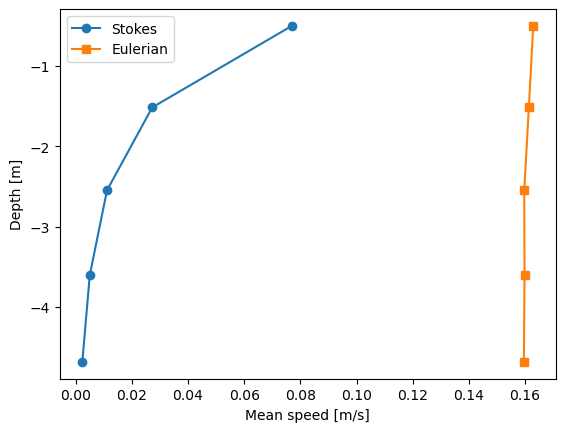

In [10]:
fig, ax = plt.subplots()

ax.plot(stokes_mean.values, -stokes_mean.depth.values, "o-", label="Stokes")
ax.plot(euler_mean.values, -euler_mean.depth.values, "s-", label="Eulerian")

ax.set_xlabel("Mean speed [m/s]")
ax.set_ylabel("Depth [m]")
ax.legend()
plt.show()

## Note on depth profile assumptions

The Stokes drift profiles above use the deep-water monochromatic
approximation applied independently to each wave partition:

- **Deep water:** The dispersion relation $k = \sigma^2 / g$ assumes
  infinite depth. In the shallow parts of the Kiel Bight (depths below
  ~15 m), finite-depth effects would increase the wavenumber and steepen
  the decay profile. For the 0--5 m depth range considered here, this is
  a minor effect.

- **Monochromatic per partition:** Each wave partition is represented by a
  single frequency and direction (Hs, Tm01, mean direction). A real wave
  spectrum is broadband, and the Stokes drift profile of a broadband
  spectrum decays more slowly than a monochromatic wave with the same
  bulk parameters. The partitioned approach is a practical middle ground
  between a single bulk wave and a full spectral integration.

- **Three partitions:** The CMEMS Baltic model provides wind waves (WW),
  primary swell (SW1), and secondary swell (SW2). In the semi-enclosed
  Baltic, wind waves typically dominate, and the swell partitions may
  carry little energy. The secondary swell (SW2) is often absent.